# ML/DL-прогнозирование и обнаружение аномалий

**Store Item Demand Forecasting — Task 3/3**

Финальный этап проекта сравнивает статистические модели, глобальные ML-модели и нейросетевые архитектуры на **одной и той же out-of-sample схеме**. Дополнительно демонстрируются три подхода к поиску аномальных наблюдений.

### Единая конфигурация

- `HORIZON = 28`
- `N_WINDOWS = 3`
- `STEP_SIZE = 28`
- `REFIT = False`
- 500 временных рядов
- **42 000 прогнозных точек на модель**

При `refit=False` модели не переобучаются с нуля на каждом CV-окне. Это уменьшает вычислительную стоимость и позволяет сохранить одинаковый режим сравнения между Task 2 и Task 3. В коде дополнительно проверяется, что прогнозируемые даты строго находятся после соответствующего `cutoff`.

### Что проверяется в этом ноутбуке

1. синхронность дат `y_true` и прогнозов;
2. одинаковые три неперекрывающихся окна по 28 дней;
3. локальное масштабирование target для глобальных ML-моделей;
4. расчёт метрик только из реальных CV-прогнозов;
5. отсутствие `np.roll`-утечки в lag features для Isolation Forest;
6. rolling Z-score только по прошлым значениям;
7. сохранение метрик и CV-прогнозов для воспроизводимости.


In [1]:
%pip -q install -U mlforecast neuralforecast lightgbm xgboost scikit-learn pyarrow statsmodels

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 261.7/261.7 kB 12.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 309.1/309.1 kB 29.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.5/3.5 MB 88.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 125.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.1/50.1 MB 21.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 348.7/348.7 kB 31.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 831.6/831.6 kB 50.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.3/78.3 MB 10.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.6/46.6 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 442.4/442.4 kB 37.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 268.7/268.7 kB 25.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.5/87.5 kB 8.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9

In [2]:
from pathlib import Path
import json
import shutil
import time
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor, IsolationForest
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor

from mlforecast import MLForecast
from mlforecast.lag_transforms import RollingMean
from mlforecast.target_transforms import LocalStandardScaler

from neuralforecast import NeuralForecast
from neuralforecast.models import NBEATS, NHITS, TFT
from neuralforecast.losses.pytorch import MAE

from statsmodels.tsa.holtwinters import ExponentialSmoothing

try:
    import torch
except Exception:
    torch = None

try:
    from google.colab import drive
    drive.mount("/content/drive")
except Exception:
    pass

SEED = 42
np.random.seed(SEED)

PROJECT_DIR = Path("/content/drive/MyDrive/time_series_final_project")
PROCESSED_DIR = PROJECT_DIR / "data" / "processed"
FIGURES_DIR = PROJECT_DIR / "reports" / "figures"
RESULTS_DIR = PROJECT_DIR / "results"

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

PREPARED_PATH = PROCESSED_DIR / "store_item_sales_prepared.csv"
assert PREPARED_PATH.exists(), f"Не найден файл: {PREPARED_PATH}"

df = pd.read_csv(PREPARED_PATH, parse_dates=["ds"])
required_cols = {"unique_id", "ds", "y", "store", "item"}
assert required_cols.issubset(df.columns), f"Не хватает колонок: {required_cols - set(df.columns)}"

df = df.sort_values(["unique_id", "ds"]).reset_index(drop=True)

assert not df.duplicated(["unique_id", "ds"]).any(), "Есть дубликаты (unique_id, ds)"
assert df["y"].notna().all(), "В y есть NaN"

# store и item должны быть статичными внутри каждого unique_id
static_check = df.groupby("unique_id")[["store", "item"]].nunique()
assert (static_check.max().max() == 1), "store/item меняются внутри unique_id"

print("shape:", df.shape)
print("series:", df["unique_id"].nunique())
print("period:", df["ds"].min().date(), "—", df["ds"].max().date())
print("GPU:", torch.cuda.get_device_name(0) if (torch is not None and torch.cuda.is_available()) else "нет")

Mounted at /content/drive
shape: (913000, 5)
series: 500
period: 2013-01-01 — 2017-12-31
GPU: Tesla T4


## 1. Общая схема валидации

Task 3 использует ту же конфигурацию backtesting, что и Task 2. Это позволяет сравнивать statistical, ML и DL-модели по одинаковым датам и одинаковому горизонту.

`REFIT=False` фиксируется как часть дизайна эксперимента. Если схема Task 2 будет изменена на `refit=True`, Task 3 также необходимо пересчитать с той же настройкой.


In [3]:
HORIZON = 28
N_WINDOWS = 3
STEP_SIZE = 28
REFIT = False

N_SERIES = df["unique_id"].nunique()
EXPECTED_ROWS = N_SERIES * N_WINDOWS * HORIZON

max_ds = df["ds"].max()
last_cutoff = max_ds - pd.Timedelta(days=HORIZON)
EXPECTED_CUTOFFS = [
    last_cutoff - pd.Timedelta(days=STEP_SIZE * k)
    for k in range(N_WINDOWS - 1, -1, -1)
]
EXPECTED_CUTOFFS = pd.DatetimeIndex(EXPECTED_CUTOFFS)

print("Expected rows per model:", EXPECTED_ROWS)
print("Expected cutoffs:", [d.date() for d in EXPECTED_CUTOFFS])

def smape_pct(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    denom = (np.abs(y_true) + np.abs(y_pred)) / 2.0
    ratio = np.divide(
        np.abs(y_true - y_pred),
        denom,
        out=np.zeros_like(denom, dtype=float),
        where=denom != 0,
    )
    return 100.0 * np.mean(ratio)

def calc_metrics(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    return {
        "sMAPE_%": smape_pct(y_true, y_pred),
        "MAE": np.mean(np.abs(y_true - y_pred)),
        "RMSE": np.sqrt(np.mean((y_true - y_pred) ** 2)),
    }

def validate_cv(cv, family, model_cols):
    required = {"unique_id", "ds", "cutoff", "y"}
    assert required.issubset(cv.columns), f"{family}: нет обязательных колонок"
    assert len(cv) == EXPECTED_ROWS, (
        f"{family}: получено {len(cv)} строк, ожидалось {EXPECTED_ROWS}"
    )
    assert not cv.duplicated(["unique_id", "ds", "cutoff"]).any(), (
        f"{family}: есть дубликаты ключа прогнозов"
    )
    assert (cv["ds"] > cv["cutoff"]).all(), f"{family}: обнаружено ds <= cutoff"
    assert cv[list(model_cols)].notna().all().all(), f"{family}: NaN в прогнозах"

    actual_cutoffs = pd.DatetimeIndex(sorted(pd.to_datetime(cv["cutoff"]).unique()))
    assert actual_cutoffs.equals(EXPECTED_CUTOFFS), (
        f"{family}: cutoffs {list(actual_cutoffs.date)} "
        f"не совпадают с ожидаемыми {list(EXPECTED_CUTOFFS.date)}"
    )
    return cv.sort_values(["unique_id", "cutoff", "ds"]).reset_index(drop=True)

def metrics_from_cv(cv, model_cols, model_type):
    rows = []
    for m in model_cols:
        rows.append({
            "model": m,
            "type": model_type,
            **calc_metrics(cv["y"], cv[m]),
        })
    return pd.DataFrame(rows).sort_values("sMAPE_%").reset_index(drop=True)

Expected rows per model: 42000
Expected cutoffs: [datetime.date(2017, 10, 8), datetime.date(2017, 11, 5), datetime.date(2017, 12, 3)]


## 2. Загрузка результатов Task 2

Статистические метрики загружаются в следующем порядке:

1. из папки проекта в Google Drive;
2. из локальной папки текущей Colab-сессии;
3. при отсутствии CSV — из сохранённого в ноутбуке snapshot результатов выполненного Task 2.

Snapshot нужен только как воспроизводимый fallback для уже рассчитанной таблицы. Если доступен актуальный `task2_metrics.csv`, приоритет всегда имеет файл с результатами запуска.


In [4]:
TASK2_METRICS_SNAPSHOT = pd.DataFrame([
    {"model": "AutoETS",       "sMAPE_%": 16.978328, "MAE": 8.329015,  "RMSE": 10.888117},
    {"model": "AutoTheta",     "sMAPE_%": 17.031804, "MAE": 8.361615,  "RMSE": 10.931076},
    {"model": "AutoARIMA",     "sMAPE_%": 18.650644, "MAE": 9.092208,  "RMSE": 11.764877},
    {"model": "SeasonalNaive", "sMAPE_%": 21.067066, "MAE": 10.499119, "RMSE": 13.982316},
    {"model": "Naive",         "sMAPE_%": 25.089491, "MAE": 13.929262, "RMSE": 18.250364},
])

task2_metric_candidates = [
    PROJECT_DIR / "results" / "task2_metrics.csv",
    Path("/content/results/task2_metrics.csv"),
    Path("results/task2_metrics.csv"),
]
task2_config_candidates = [
    PROJECT_DIR / "results" / "task2_cv_config.json",
    Path("/content/results/task2_cv_config.json"),
    Path("results/task2_cv_config.json"),
]

task2_path = next((p for p in task2_metric_candidates if p.exists()), None)
task2_config_path = next((p for p in task2_config_candidates if p.exists()), None)

if task2_path is not None:
    stat_metrics = pd.read_csv(task2_path)
    stat_source = str(task2_path)
else:
    stat_metrics = TASK2_METRICS_SNAPSHOT.copy()
    stat_source = "snapshot результатов Task 2, сохранённый в ноутбуке"

# Если config найден, обязательно проверяем общую схему CV.
if task2_config_path is not None:
    with open(task2_config_path, encoding="utf-8") as f:
        task2_cfg = json.load(f)

    assert int(task2_cfg["horizon"]) == HORIZON, (
        f"Task2 horizon={task2_cfg['horizon']} != {HORIZON}"
    )
    assert int(task2_cfg["n_windows"]) == N_WINDOWS, (
        f"Task2 n_windows={task2_cfg['n_windows']} != {N_WINDOWS}"
    )
    assert int(task2_cfg["step_size"]) == STEP_SIZE, (
        f"Task2 step_size={task2_cfg['step_size']} != {STEP_SIZE}"
    )

    # Если конфигурация Task 2 содержит поле refit, проверяем и его.
    if "refit" in task2_cfg:
        assert bool(task2_cfg["refit"]) == REFIT, (
            f"Task2 refit={task2_cfg['refit']} != {REFIT}"
        )

stat_metrics["type"] = "Statistical"

print("Источник статистических метрик:", stat_source)
print("Task2 config:", task2_config_path if task2_config_path else "не найден; используем известную текущую схему")
display(stat_metrics)

stat_metrics.to_csv(
    RESULTS_DIR / "task2_metrics_used_by_task3.csv",
    index=False
)

Источник статистических метрик: snapshot результатов Task 2, сохранённый в ноутбуке
Task2 config: не найден; используем известную текущую схему


,model,sMAPE_%,MAE,RMSE,type
0,AutoETS,16.978328,8.329015,10.888117,Statistical
1,AutoTheta,17.031804,8.361615,10.931076,Statistical
2,AutoARIMA,18.650644,9.092208,11.764877,Statistical
3,SeasonalNaive,21.067066,10.499119,13.982316,Statistical
4,Naive,25.089491,13.929262,18.250364,Statistical


## 3. Глобальные ML-модели

Сравниваются:

- `LightGBM`;
- `XGBoost`;
- `RandomForest`.

### Признаки

- лаги: `1, 7, 14, 28`;
- rolling mean по прошлым значениям;
- календарные признаки: `dayofweek`, `month`;
- статические признаки: `store`, `item`.

`LocalStandardScaler` масштабирует target **отдельно внутри каждого временного ряда**, что важно из-за заметных различий в уровне спроса между `store-item`.

При `refit=False` модели обучаются в начале CV и затем используются для прогнозирования следующих окон без полного переобучения.


In [5]:
df_ml = df[["unique_id", "ds", "y", "store", "item"]].copy()

ml_models = {
    "LightGBM": LGBMRegressor(
        n_estimators=350,
        learning_rate=0.05,
        num_leaves=31,
        subsample=0.9,
        colsample_bytree=0.9,
        random_state=SEED,
        verbosity=-1,
    ),
    "XGBoost": XGBRegressor(
        n_estimators=350,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.9,
        colsample_bytree=0.9,
        objective="reg:squarederror",
        random_state=SEED,
        n_jobs=-1,
    ),
    "RandomForest": RandomForestRegressor(
        n_estimators=220,
        max_depth=16,
        min_samples_leaf=2,
        random_state=SEED,
        n_jobs=-1,
    ),
}

mlf = MLForecast(
    models=ml_models,
    freq="D",
    lags=[1, 7, 14, 28],
    lag_transforms={
        1: [RollingMean(window_size=7), RollingMean(window_size=28)],
        7: [RollingMean(window_size=7)],
    },
    date_features=["dayofweek", "month"],
    target_transforms=[LocalStandardScaler()],
    num_threads=-1,
)

t0 = time.time()
cv_ml = mlf.cross_validation(
    df=df_ml,
    n_windows=N_WINDOWS,
    h=HORIZON,
    step_size=STEP_SIZE,
    static_features=["store", "item"],
    refit=REFIT,
)
ml_elapsed = time.time() - t0

ml_model_cols = [m for m in ml_models if m in cv_ml.columns]
assert len(ml_model_cols) == 3, f"Не найдены все ML-прогнозы: {cv_ml.columns.tolist()}"

cv_ml = validate_cv(cv_ml, "ML", ml_model_cols)
ml_metrics = metrics_from_cv(cv_ml, ml_model_cols, "ML")

print(f"ML CV: {ml_elapsed/60:.2f} мин")
display(ml_metrics)

cv_ml.to_parquet(RESULTS_DIR / "task3_ml_cv_predictions.parquet", index=False)
ml_metrics.to_csv(RESULTS_DIR / "task3_ml_metrics.csv", index=False)

with open(RESULTS_DIR / "task3_ml_config.json", "w", encoding="utf-8") as f:
    json.dump({
        "horizon": HORIZON,
        "n_windows": N_WINDOWS,
        "step_size": STEP_SIZE,
        "refit": REFIT,
        "n_series": int(N_SERIES),
        "models": ml_model_cols,
        "elapsed_sec_total": ml_elapsed,
    }, f, ensure_ascii=False, indent=2)

ML CV: 23.30 мин


,model,type,sMAPE_%,MAE,RMSE
0,XGBoost,ML,12.975293,6.167533,8.101489
1,LightGBM,ML,13.041830,6.200371,8.140690
2,RandomForest,ML,13.083107,6.194304,8.112272


### Качество ML-моделей по отдельным рядам

Помимо общей sMAPE, ошибка рассчитывается отдельно для каждого из 500 `unique_id`. Это позволяет увидеть распределение качества и проверить, не скрывает ли средняя метрика слабые результаты на отдельных сериях.


In [6]:
ml_per_series = []
for uid, g in cv_ml.groupby("unique_id", sort=False):
    for m in ml_model_cols:
        ml_per_series.append({
            "unique_id": uid,
            "model": m,
            "sMAPE_%": smape_pct(g["y"], g[m]),
        })

ml_per_series = pd.DataFrame(ml_per_series)
display(
    ml_per_series.groupby("model")["sMAPE_%"]
    .agg(["mean", "median", "std", "min", "max"])
    .sort_values("mean")
)
ml_per_series.to_csv(
    RESULTS_DIR / "task3_ml_per_series_smape.csv",
    index=False
)

,mean,median,std,min,max
model,,,,,
XGBoost,12.975293,12.238206,3.368046,7.212321,24.732042
LightGBM,13.041830,12.311023,3.355164,7.460438,24.664169
RandomForest,13.083107,12.380497,3.436329,7.263238,24.407772


## 4. Нейросетевые модели

Сравниваются три архитектуры `NeuralForecast`:

- `NBEATS`;
- `NHITS`;
- `TFT`.

Для всех моделей используется та же схема `3 × 28`, `refit=False`.  
`scaler_type="robust"` задан явно, поскольку серии заметно различаются по масштабу и содержат локальные экстремальные значения.

`val_size=0` означает, что отдельное внутреннее validation-окно в каждом CV-fold не выделяется; early stopping в данной конфигурации не используется.


In [7]:
RUN_DL = True

if RUN_DL:
    df_dl = df[["unique_id", "ds", "y"]].copy()

    trainer_kwargs = {}
    if torch is not None and torch.cuda.is_available():
        trainer_kwargs = {"accelerator": "gpu", "devices": 1}

    dl_models = [
        NBEATS(
            h=HORIZON,
            input_size=5 * HORIZON,
            max_steps=200,
            learning_rate=5e-4,
            batch_size=128,
            scaler_type="robust",
            loss=MAE(),
            random_seed=SEED,
            alias="NBEATS",
            enable_progress_bar=False,
            **trainer_kwargs,
        ),
        NHITS(
            h=HORIZON,
            input_size=5 * HORIZON,
            max_steps=200,
            learning_rate=5e-4,
            batch_size=128,
            scaler_type="robust",
            loss=MAE(),
            random_seed=SEED,
            alias="NHITS",
            enable_progress_bar=False,
            **trainer_kwargs,
        ),
        TFT(
            h=HORIZON,
            input_size=5 * HORIZON,
            hidden_size=32,
            dropout=0.2,
            max_steps=200,
            learning_rate=5e-4,
            batch_size=128,
            scaler_type="robust",
            loss=MAE(),
            random_seed=SEED,
            alias="TFT",
            enable_progress_bar=False,
            **trainer_kwargs,
        ),
    ]

    nf = NeuralForecast(models=dl_models, freq="D")

    t0 = time.time()
    cv_dl = nf.cross_validation(
        df=df_dl,
        n_windows=N_WINDOWS,
        step_size=STEP_SIZE,
        val_size=0,
        refit=REFIT,
    )
    dl_elapsed = time.time() - t0

    dl_candidates = ["NBEATS", "NHITS", "TFT"]
    dl_model_cols = [m for m in dl_candidates if m in cv_dl.columns]
    assert len(dl_model_cols) == 3, (
        f"Не найдены все DL-прогнозы. Колонки: {cv_dl.columns.tolist()}"
    )

    cv_dl = validate_cv(cv_dl, "DL", dl_model_cols)
    dl_metrics = metrics_from_cv(cv_dl, dl_model_cols, "DL")

    print(f"DL CV: {dl_elapsed/60:.2f} мин")
    display(dl_metrics)

    cv_dl.to_parquet(
        RESULTS_DIR / "task3_dl_cv_predictions.parquet",
        index=False
    )
    dl_metrics.to_csv(
        RESULTS_DIR / "task3_dl_metrics.csv",
        index=False
    )

    with open(RESULTS_DIR / "task3_dl_config.json", "w", encoding="utf-8") as f:
        json.dump({
            "horizon": HORIZON,
            "n_windows": N_WINDOWS,
            "step_size": STEP_SIZE,
            "refit": REFIT,
            "n_series": int(N_SERIES),
            "models": dl_model_cols,
            "max_steps": 200,
            "elapsed_sec_total": dl_elapsed,
        }, f, ensure_ascii=False, indent=2)
else:
    cv_dl = None
    dl_metrics = pd.DataFrame(
        columns=["model", "type", "sMAPE_%", "MAE", "RMSE"]
    )

DL CV: 0.65 мин


,model,type,sMAPE_%,MAE,RMSE
0,NHITS,DL,13.909004,6.631257,8.708983
1,NBEATS,DL,13.916908,6.634835,8.741328
2,TFT,DL,20.084122,10.302626,13.430571


## 5. Сравнение всех моделей

Статистические, ML и DL-результаты объединяются только после автоматических проверок:

- ожидаемое число строк;
- отсутствие дубликатов;
- отсутствие пропусков в прогнозах;
- условие `ds > cutoff`;
- точное совпадение трёх ожидаемых cutoff.

Таким образом, все метрики рассчитываются по согласованным `y_true` и прогнозам для одних и тех же дат.


,model,type,sMAPE_%,MAE,RMSE
0,XGBoost,ML,12.975293,6.167533,8.101489
1,LightGBM,ML,13.041830,6.200371,8.140690
2,RandomForest,ML,13.083107,6.194304,8.112272
3,NHITS,DL,13.909004,6.631257,8.708983
4,NBEATS,DL,13.916908,6.634835,8.741328
5,AutoETS,Statistical,16.978328,8.329015,10.888117
6,AutoTheta,Statistical,17.031804,8.361615,10.931076
7,AutoARIMA,Statistical,18.650644,9.092208,11.764877
8,TFT,DL,20.084122,10.302626,13.430571
9,SeasonalNaive,Statistical,21.067066,10.499119,13.982316


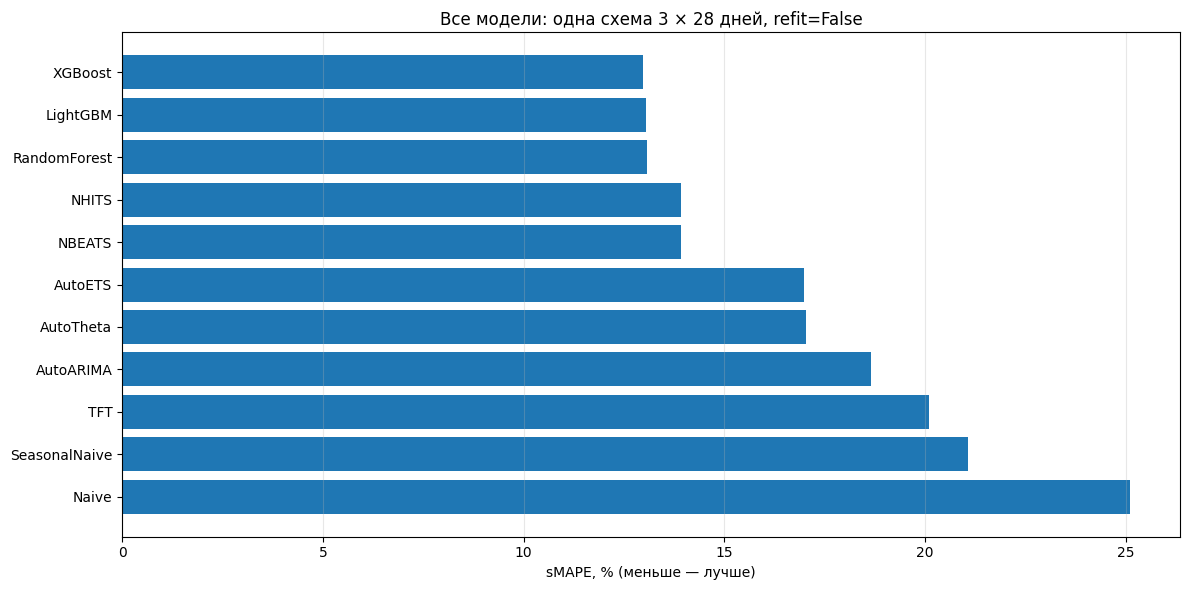

In [8]:
common_cols = ["model", "type", "sMAPE_%", "MAE", "RMSE"]

parts = [
    stat_metrics[common_cols],
    ml_metrics[common_cols],
]
if len(dl_metrics):
    parts.append(dl_metrics[common_cols])

final_results = (
    pd.concat(parts, ignore_index=True)
    .sort_values("sMAPE_%")
    .reset_index(drop=True)
)

display(final_results)
final_results.to_csv(
    RESULTS_DIR / "task3_all_model_metrics.csv",
    index=False
)

fig, ax = plt.subplots(figsize=(12, 6))
ordered = final_results.sort_values("sMAPE_%", ascending=True)
ax.barh(ordered["model"][::-1], ordered["sMAPE_%"][::-1])
ax.set_xlabel("sMAPE, % (меньше — лучше)")
ax.set_title("Все модели: одна схема 3 × 28 дней, refit=False")
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.savefig(
    FIGURES_DIR / "task3_model_comparison_FIXED.png",
    dpi=150,
    bbox_inches="tight",
)
plt.show()

## 6. Ошибка по горизонту прогноза

Для multi-step forecasting важно оценивать не только среднюю ошибку за 28 дней, но и её изменение от `h=1` до `h=28`.

Этот анализ показывает, насколько быстро ухудшается качество модели по мере удаления от даты `cutoff`.


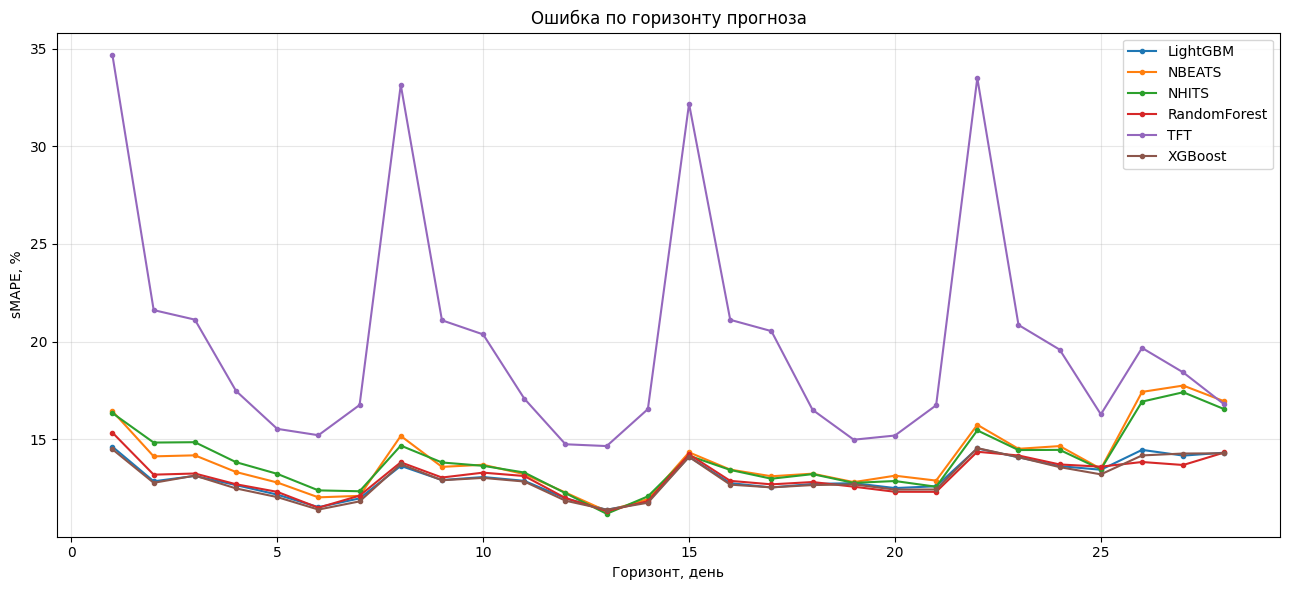

In [9]:
def add_horizon_index(cv):
    out = cv.copy()
    out["h"] = out.groupby(["unique_id", "cutoff"]).cumcount() + 1
    return out

horizon_rows = []

ml_h = add_horizon_index(cv_ml)
for m in ml_model_cols:
    for h, g in ml_h.groupby("h", sort=True):
        horizon_rows.append({
            "h": int(h),
            "model": m,
            "sMAPE_%": smape_pct(g["y"], g[m]),
        })

if cv_dl is not None:
    dl_h = add_horizon_index(cv_dl)
    for m in dl_model_cols:
        for h, g in dl_h.groupby("h", sort=True):
            horizon_rows.append({
                "h": int(h),
                "model": m,
                "sMAPE_%": smape_pct(g["y"], g[m]),
            })

horizon_metrics = pd.DataFrame(horizon_rows)
horizon_metrics.to_csv(
    RESULTS_DIR / "task3_smape_by_horizon.csv",
    index=False
)

fig, ax = plt.subplots(figsize=(13, 6))
for model, g in horizon_metrics.groupby("model"):
    ax.plot(g["h"], g["sMAPE_%"], marker="o", markersize=3, label=model)

ax.set_xlabel("Горизонт, день")
ax.set_ylabel("sMAPE, %")
ax.set_title("Ошибка по горизонту прогноза")
ax.grid(True, alpha=0.3)
ax.legend()

plt.tight_layout()
plt.savefig(
    FIGURES_DIR / "task3_smape_by_horizon.png",
    dpi=150,
    bbox_inches="tight",
)
plt.show()

## 7. Обнаружение аномалий на `store_1_item_1`

Сравниваются три диагностических подхода:

1. **Rolling Z-score** — среднее и стандартное отклонение рассчитываются только по прошлым наблюдениям через `shift(1)`;
2. **ETS residual diagnostic** — аномалии определяются по большим in-sample остаткам ETS относительно robust MAD-порога;
3. **Isolation Forest** — используются текущее значение, настоящие lag features через `shift` и rolling-признаки без wrap-around leakage.

Эти методы отвечают на разные вопросы, поэтому количество найденных точек не должно совпадать. Флаг anomaly означает только необычность наблюдения по конкретному правилу и не объясняет бизнес-причину.


In [10]:
example_id = "store_1_item_1"
one = (
    df[df["unique_id"].eq(example_id)][["ds", "y"]]
    .sort_values("ds")
    .reset_index(drop=True)
)
s = one.set_index("ds")["y"].astype(float)

# ------------------------------------------------------------
# 1) Rolling Z-score: только прошлое
# ------------------------------------------------------------
window = 30
roll_mean = s.shift(1).rolling(window, min_periods=window).mean()
roll_std = s.shift(1).rolling(window, min_periods=window).std(ddof=1)

z = (s - roll_mean) / roll_std.replace(0, np.nan)
z_anom = z.abs() > 3

z_df = pd.DataFrame({
    "ds": s.index,
    "y": s.values,
    "zscore": z.values,
    "is_anomaly": z_anom.fillna(False).values,
})

# ------------------------------------------------------------
# 2) ETS in-sample residual diagnostic
# ------------------------------------------------------------
ets = ExponentialSmoothing(
    s,
    trend="add",
    seasonal="add",
    seasonal_periods=7,
    initialization_method="estimated",
).fit(optimized=True)

ets_resid = s - ets.fittedvalues

# Robust threshold через median/MAD
resid_center = ets_resid.median()
mad = np.median(np.abs(ets_resid - resid_center))
robust_sigma = 1.4826 * mad if mad > 0 else ets_resid.std(ddof=1)

ets_anom = (ets_resid - resid_center).abs() > 3 * robust_sigma

ets_df = pd.DataFrame({
    "ds": s.index,
    "y": s.values,
    "residual": ets_resid.values,
    "is_anomaly": ets_anom.fillna(False).values,
})

# ------------------------------------------------------------
# 3) Isolation Forest: настоящие lag features через shift
# ------------------------------------------------------------
iso = pd.DataFrame({"ds": s.index, "y": s.values})

for lag in [7, 14, 21, 28]:
    iso[f"lag_{lag}"] = s.shift(lag).values

iso["rolling_mean_7"] = s.shift(1).rolling(7).mean().values
iso["rolling_std_7"] = s.shift(1).rolling(7).std(ddof=1).values
iso = iso.dropna().reset_index(drop=True)

feature_cols = [
    "y",
    "lag_7",
    "lag_14",
    "lag_21",
    "lag_28",
    "rolling_mean_7",
    "rolling_std_7",
]

iforest = IsolationForest(
    n_estimators=300,
    contamination="auto",
    random_state=SEED,
    n_jobs=-1,
)
iso["iforest_label"] = iforest.fit_predict(iso[feature_cols])
iso["is_anomaly"] = iso["iforest_label"].eq(-1)

print("Rolling Z anomalies:", int(z_df["is_anomaly"].sum()))
print("ETS residual anomalies:", int(ets_df["is_anomaly"].sum()))
print("Isolation Forest anomalies:", int(iso["is_anomaly"].sum()))
print(
    "Isolation Forest anomaly share:",
    f"{100 * iso['is_anomaly'].mean():.2f}%",
    "(доля не задана заранее как 5%)",
)

Rolling Z anomalies: 20
ETS residual anomalies: 9
Isolation Forest anomalies: 275
Isolation Forest anomaly share: 15.29% (доля не задана заранее как 5%)


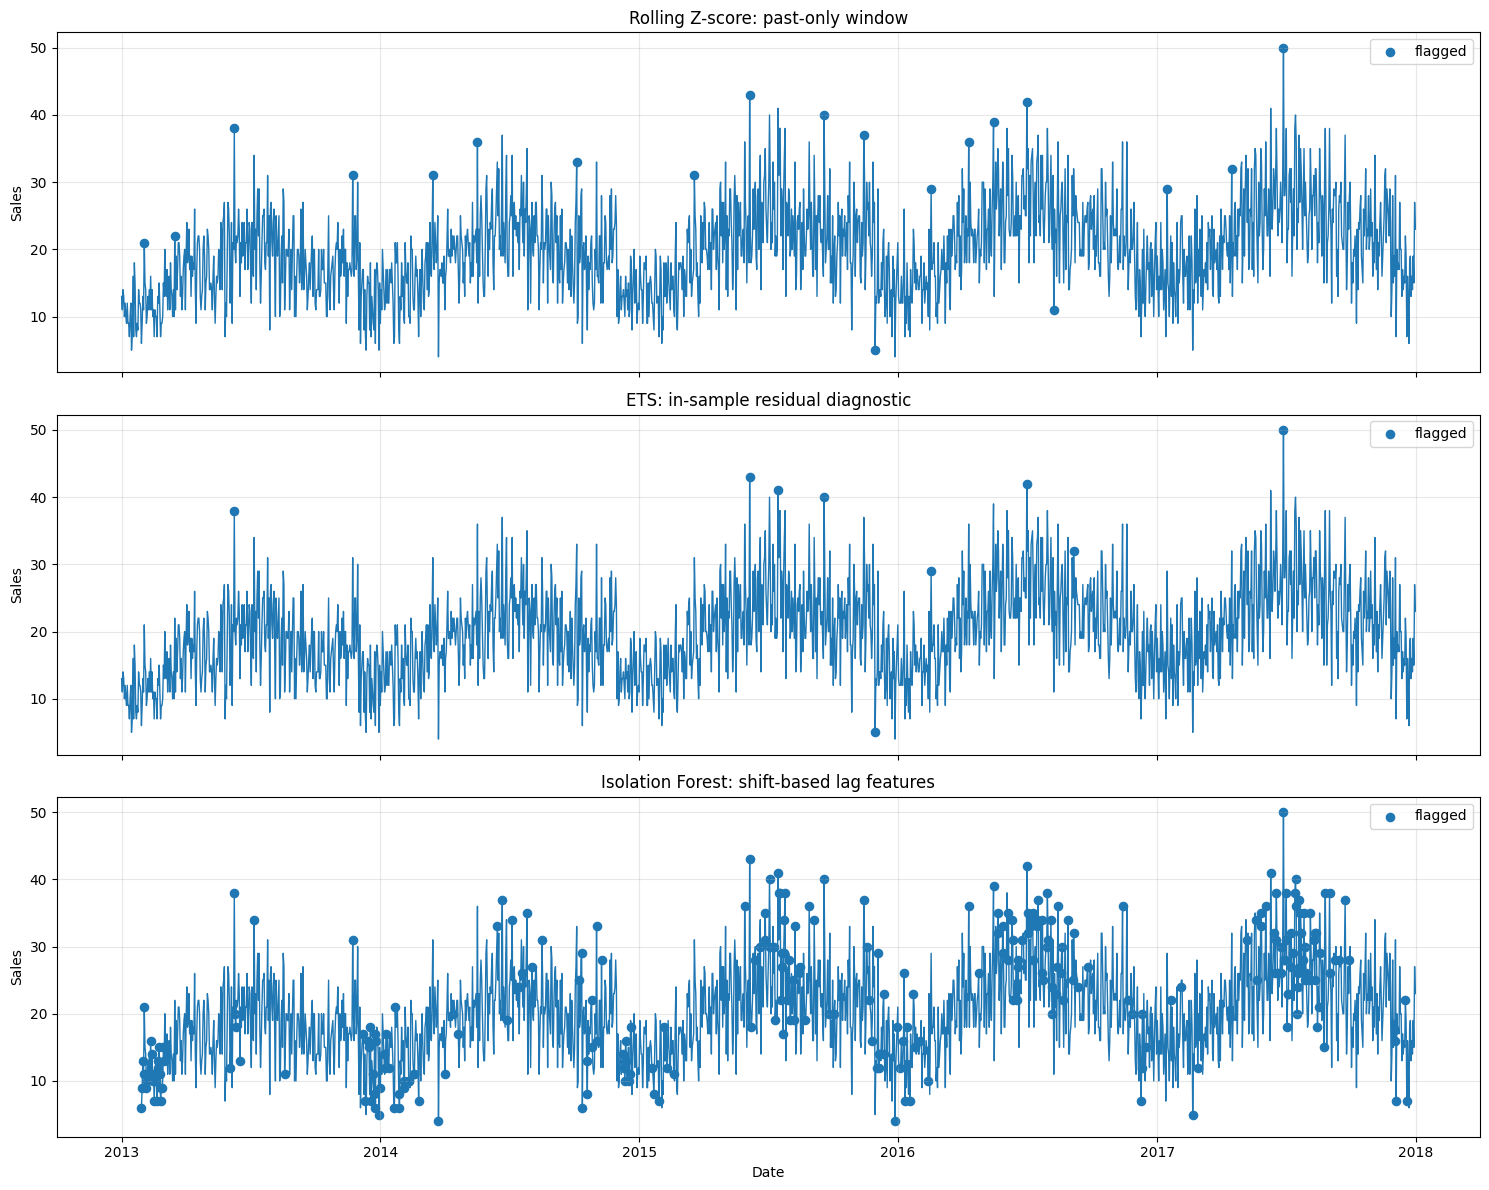

In [11]:
fig, axes = plt.subplots(3, 1, figsize=(15, 12), sharex=True)

for ax, dat, title in [
    (axes[0], z_df, "Rolling Z-score: past-only window"),
    (axes[1], ets_df, "ETS: in-sample residual diagnostic"),
    (axes[2], iso, "Isolation Forest: shift-based lag features"),
]:
    ax.plot(dat["ds"], dat["y"], linewidth=1)
    flagged = dat[dat["is_anomaly"]]
    ax.scatter(
        flagged["ds"],
        flagged["y"],
        s=35,
        label="flagged",
    )
    ax.set_title(title)
    ax.set_ylabel("Sales")
    ax.grid(True, alpha=0.3)
    ax.legend()

axes[-1].set_xlabel("Date")
plt.tight_layout()
plt.savefig(
    FIGURES_DIR / "task3_anomalies_FIXED.png",
    dpi=150,
    bbox_inches="tight",
)
plt.show()

## 8. Правила интерпретации

- Модели сравниваются по **реально рассчитанной out-of-sample sMAPE** на одной схеме backtesting.
- `100 - sMAPE` не является accuracy и в проекте так не интерпретируется.
- Если одна модель показывает меньшую ошибку, вывод относится к **этой конфигурации данных, признаков и CV**, а не к классу алгоритмов в целом.
- Результаты anomaly detection являются диагностическими флагами, а не размеченной «истиной» об аномалиях.


In [12]:
print("FINAL TASK 3 SUMMARY")
print("=" * 80)
print(final_results.to_string(index=False, float_format=lambda x: f"{x:.3f}"))
print()
print("CV:")
print(f"  horizon     = {HORIZON}")
print(f"  n_windows   = {N_WINDOWS}")
print(f"  step_size   = {STEP_SIZE}")
print(f"  refit       = {REFIT}")
print(f"  rows/model  = {EXPECTED_ROWS:,}")
print("  cutoffs     =", [d.date() for d in EXPECTED_CUTOFFS])
print()
print("Сохранено в:", RESULTS_DIR)
print("Для README и резюме используются метрики из этой финальной таблицы после полного запуска.")

FINAL TASK 3 SUMMARY
        model        type  sMAPE_%    MAE   RMSE
      XGBoost          ML   12.975  6.168  8.101
     LightGBM          ML   13.042  6.200  8.141
 RandomForest          ML   13.083  6.194  8.112
        NHITS          DL   13.909  6.631  8.709
       NBEATS          DL   13.917  6.635  8.741
      AutoETS Statistical   16.978  8.329 10.888
    AutoTheta Statistical   17.032  8.362 10.931
    AutoARIMA Statistical   18.651  9.092 11.765
          TFT          DL   20.084 10.303 13.431
SeasonalNaive Statistical   21.067 10.499 13.982
        Naive Statistical   25.089 13.929 18.250

CV:
  horizon     = 28
  n_windows   = 3
  step_size   = 28
  refit       = False
  rows/model  = 42,000
  cutoffs     = [datetime.date(2017, 10, 8), datetime.date(2017, 11, 5), datetime.date(2017, 12, 3)]

Сохранено в: /content/drive/MyDrive/time_series_final_project/results
Для README и резюме используются метрики из этой финальной таблицы после полного запуска.


## 9. Итоговые результаты

| Модель | Тип | sMAPE, % | MAE | RMSE |
|---|---|---:|---:|---:|
| **XGBoost** | ML | **12.975** | **6.168** | **8.101** |
| LightGBM | ML | 13.042 | 6.200 | 8.141 |
| RandomForest | ML | 13.083 | 6.194 | 8.112 |
| NHITS | DL | 13.909 | 6.631 | 8.709 |
| NBEATS | DL | 13.917 | 6.635 | 8.741 |
| AutoETS | Statistical | 16.978 | 8.329 | 10.888 |
| AutoTheta | Statistical | 17.032 | 8.362 | 10.931 |
| AutoARIMA | Statistical | 18.651 | 9.092 | 11.765 |
| TFT | DL | 20.084 | 10.303 | 13.431 |
| SeasonalNaive | Statistical | 21.067 | 10.499 | 13.982 |
| Naive | Statistical | 25.089 | 13.929 | 18.250 |

### Основные наблюдения

- Минимальную sMAPE в этом эксперименте показывает **XGBoost — 12.98%**.
- По сравнению с лучшей статистической моделью `AutoETS` sMAPE ниже на **4.00 процентного пункта**, или примерно на **23.6% относительно**.
- `LightGBM` и `RandomForest` дают очень близкие результаты, поэтому преимущество XGBoost над другими tree-based ML-моделями небольшое.
- `NHITS` и `NBEATS` превосходят статистические модели в этой конфигурации, но уступают трём глобальным ML-моделям.
- `TFT` при текущих гиперпараметрах показывает более высокую ошибку, чем `AutoETS`, что подчёркивает важность настройки архитектуры и режима обучения.
- Три метода anomaly detection отмечают разное число наблюдений: это ожидаемо, поскольку у них разные определения «необычности».

> Итоговые значения относятся к схеме `3 × 28`, `refit=False`. Для более строгой оценки устойчивости результата полезно дополнительно проверить больше временных окон и отдельно сравнить режим с переобучением на каждом cutoff.
